# Cluster Latent Space

## 1. Load Data

In [1]:
"""Cluster Latent Space

Structure:
    1.1. Imports, Variables, Functions
    1.2. Load Data
"""

# 1.1 Imports, Variables, Functions
# imports   
import sys
sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)
import importlib
import scanpy as sc
from src.utils import utils 

importlib.reload(ut)
importlib.reload(vz)


# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05") 
run_dir = os.path.join("..","..","outputs","run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01") 
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_type = "ft"

assert embedding_type in ["ft", "pt", "raw"]
if embedding_type == "ft":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions
def get_counts(df:pd.DataFrame, rel_map:Dict, key_interest:str)->pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = [], [], [], [], [], []
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)           # absolute count of the exact disease
        rel  = sum(1 for x in topk if x in related)        # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel
        
        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related)+1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"]   = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"]  = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"]   = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"]  = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]
    
    df_query["old_prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]
    df_query["old_recall@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_universe_related"]
    df_query["prec@k"] = (df_query["n_rel_uniq"]+df_query["n_same_uniq"]) / df_query["n_total_unique"]
    df_query["recall@k"] = (df_query["n_rel_uniq"]+df_query["n_same_uniq"]) / df_query["n_universe_related"]

    return df_query

# 1.2 Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: no control loss
library: RNA-Seq
use_controls: True


In [2]:

split_idx = 0

# load all adata
adata_test =  sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

In [3]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    print(f"Loaded ft embeddings from all_outputs")
elif embedding_type == "pt":
    # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
    # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
    # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
    # embeddings_test = pt_adata_test.obsm["X_scGPT"]
    # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
    # embeddings_train = pt_adata_train.obsm["X_scGPT"]

    embeddings_test = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "test-pt_embeddings.npy"))
    embeddings_valid = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "valid-pt_embeddings.npy"))
    embeddings_train = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "train-pt_embeddings.npy"))
    print(f"Loaded pt embeddings from npy files")
elif embedding_type == "raw":
    embeddings_test = np.array(adata_test.X)
    embeddings_valid = np.array(adata_valid.X)
    embeddings_train = np.array(adata_train.X)

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
    print(f"Loaded raw embeddings from adata.X")

Using ft embeddings
Loaded ft embeddings from all_outputs


In [4]:
# Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


Loaded universe of disease pairs: 70442515


In [5]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | \
                    set(_do_df.loc[_do_df["do2"] == d, "do1"])

IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


## 2. Process Data

In [6]:
# imports
import importlib
importlib.reload(ut)

# variables
remove_control_train = True
remove_control_test = True
custom_splits = False
merge_train_valid = False
thr_related = 1.0

# functions
def custom_train_valid_split(df, random_state=42, remove_control:bool=False)->Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        df_controls = df[df["doid_id"] == "Control"]

    valid_datasets = set()
    train_datasets = set()
    # Loop through diseases
    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # df_controls handled when splitting real diseases
        
        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        n_overlap_valid = len(valid_datasets & set(datasets))
        if (n_overlap_valid>0) & (len(datasets)-n_overlap_valid)>0:   # if dataset already placed in valid set

            # place existing dataset in valid for this disease
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[~df_do["dataset"].isin(valid_datasets)].index)

        elif len(datasets)-n_overlap_valid > 1:
            rng.shuffle(list(datasets))
            new_valid_datasets = {d for d in datasets if d not in valid_datasets}  # datasets not already in valid
            new_valid_datasets = {list(new_valid_datasets)[0]}  # take one new dataset for valid
            new_train_datasets = set(datasets) - new_valid_datasets - valid_datasets

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(new_valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(new_train_datasets)].index)

            valid_datasets.update(new_valid_datasets)
            train_datasets.update(new_train_datasets)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = df_controls[df_controls["dataset"].isin(new_valid_datasets)].index
                ctrl_train = df_controls[df_controls["dataset"].isin(new_train_datasets)].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            n_valid_ds = max(1, len(idx) // 6)
            valid_idx.append(idx[n_valid_ds-1])
            train_idx.extend(idx[n_valid_ds:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:            
                ctrl_ds = df_controls[df_controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    n_valid_ds = max(1, len(ctrl_ds) // 6)
                    valid_idx.append(ctrl_ds[n_valid_ds-1])
                    train_idx.extend(ctrl_ds[n_valid_ds:])

    return np.array(train_idx), np.array(valid_idx)

# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_train = adata_train.obs.copy()
df_valid = adata_valid.obs.copy()
df_test = adata_test.obs.copy()

e_train = embeddings_train
e_valid = embeddings_valid
e_test = embeddings_test

if remove_control_train:
    all_doids.remove("Control")

    mask_train = df_train["doid_id"] != "Control"
    mask_valid = df_valid["doid_id"] != "Control"

    e_train = e_train[mask_train.values]
    e_valid = e_valid[mask_valid.values]

    df_train = df_train[mask_train].reset_index(drop=True)
    df_valid = df_valid[mask_valid].reset_index(drop=True)

if remove_control_test:
    mask_test = df_test["doid_id"] != "Control"

    e_test = e_test[mask_test.values]

    df_test = df_test[mask_test].reset_index(drop=True)


if custom_splits:
    df_train_all = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train_all = df_train_all.reset_index(drop=True)

    # RE-SPLIT TRAIN/VALIDATION SET
    train_idx, valid_idx = custom_train_valid_split(df_train_all, remove_control=remove_control_train)
    df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
    df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

    e_train_all = np.concatenate([e_train, e_valid], axis=0)
    e_train = e_train_all[train_idx]
    e_valid = e_train_all[valid_idx]

if merge_train_valid:
    df_train = pd.concat([df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0)
    df_train = df_train.reset_index(drop=True)
    e_train =  np.concatenate([e_train, e_valid], axis=0)
    
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

else:
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_valid = ut.get_multilabel_y(df_valid, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

print(f"Nº of diseases train: {df_train['doid_id'].nunique()}\tNº of diseases valid: {df_valid['doid_id'].nunique()}")
print(f"Nº of samples train: {df_train.shape[0]}\tNº of samples valid: {df_valid.shape[0]}")
print(f"Nº unique datasets train: {df_train['dataset'].nunique()}\tNº unique datasets valid: {df_valid['dataset'].nunique()}")
print(f"Nº overlap datasets train/valid: {len(set(df_train['dataset'].unique()) & set(df_valid['dataset'].unique()))}")


Nº of diseases train: 123	Nº of diseases valid: 106
Nº of samples train: 11823	Nº of samples valid: 1314
Nº unique datasets train: 471	Nº unique datasets valid: 304
Nº overlap datasets train/valid: 304


## 3. Cluster Space

### 3.1 K-Means

In [7]:
# imports
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from scipy.stats import hypergeom
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from scipy.special import softmax

# variables
plot_elbow = True
# k_ideal = 25
_k_candidates = np.arange(2, int(np.sqrt(len(e_train))*5)+1, 50)
_k_candidates = [2, 10, 25, 30, 35, 50, 75, 100, 150, 200]
_k_candidates = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 75, 100]
do_cosine_dist = True   # https://stackoverflow.com/questions/46409846/using-k-means-with-cosine-similarity-python
ALPHA = 0.05    # significance threshold for enrichment - could also add Bonferroni correction

# functions
def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def evaluate_clusters(preds, labels, embs, metric:str="cosine"):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

    # Convert true labels once here
    if labels is not None:
        labels = np.array(labels).astype(str)

    # Core clustering metric

    # Geometry metrics
    Sil = silhouette_score(embs, preds.astype(int), metric=metric)  # silhouette requires integers
    CH = calinski_harabasz_score(embs, preds.astype(int))
    DB = davies_bouldin_score(embs, preds.astype(int))

    # Label-based metrics
    Purity = cluster_purity(labels, preds)
    NMI = normalized_mutual_info_score(labels, preds)
    ARI = adjusted_rand_score(labels, preds)
    AMI = adjusted_mutual_info_score(labels, preds)

    return {
        "Silhouette": Sil,  #
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
    }

def plot_metric(df_results, key)->None: 
    plt.figure(figsize=(8, 5))
    plt.plot(df_results["k"], df_results[key], marker='o', linewidth=2, markersize=5)

    plt.title(f"{key} Score vs k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(f"{key} Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_hypergeom_enrichment(clusters, labels):
    """
    clusters: np.array of cluster assignments (ints or strings)
    labels:   np.array of disease labels (strings recommended)
    """

    # Ensure everything is string for safety
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)  # total samples

    unique_clusters = np.unique(clusters)
    unique_diseases = np.unique(labels)

    results = []

    for cluster_id in unique_clusters:
        cluster_mask = (clusters == cluster_id)
        n = np.sum(cluster_mask)  # cluster size

        for disease in unique_diseases:
            K = np.sum(labels == disease)               # total disease count in dataset
            k = np.sum((labels == disease) & cluster_mask)  # disease count in cluster

            if k == 0:
                continue  # no enrichment possible

            # Hypergeometric test (enrichment = P(X >= k))
            pval = hypergeom.sf(k - 1, N, K, n)

            results.append({
                "cluster": int(cluster_id),
                "disease": disease,
                "k_in_cluster": k,
                "K_total": K,
                "cluster_size": n,
                "total_N": N,
                "p_value": pval
            })

    # Return as DataFrame sorted by p-value (more enriched = smaller p)
    df = pd.DataFrame(results)
    df = df.sort_values(["cluster", "p_value"])

    return df

def get_multilab_pred(cluster_scores:np.array, clust_to_dis:Dict, dis_ord:np.array, clust_ord:np.array)->np.array:
    n_samples = len(cluster_scores)
    n_diseases = len(dis_ord)

    # idx of disease corresponds to dis_ord
    dis_to_idx = {k:v for v, k in enumerate(dis_ord)}

    y_pred = np.zeros((n_samples, n_diseases))
    for i in range(n_samples):
        for j in clust_ord: # loop through different cluster orders
            _dis = clust_to_dis.get(j, [])
            _dis_idxs = [dis_to_idx[k] for k in _dis]
            y_pred[i, _dis_idxs] = np.maximum(y_pred[i, _dis_idxs], cluster_scores[i, j]) # assign max score among clusters
            
    return y_pred

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]  # (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()

def get_recall_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]  # (N_samples, k)
    denom = y_true.sum(axis=1).astype(float)
    denom[denom == 0] = 1.0  # avoid div by 0
    return (y_topk.sum(axis=1) / denom).mean()


def get_precision_at_top_score(y_pred, y_true):
    """
    Precision where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    precisions = []

    for i in range(N):
        # highest score in this sample
        max_score = y_pred[i].max()

        # all labels tied for highest score
        top_idxs = np.where(y_pred[i] == max_score)[0]

        # true positives among these
        tp = y_true[i, top_idxs].sum()

        # precision for this sample
        precisions.append(tp / len(top_idxs))

    return np.mean(precisions)

def get_recall_at_top_score(y_pred, y_true):
    """
    Recall where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    recalls = []

    for i in range(N):
        # all ground-truth positive labels for this sample
        true_pos = np.where(y_true[i] == 1)[0]

        if len(true_pos) == 0:
            # skip samples with no positives (or define recall=1.0)
            continue

        # highest predicted score
        max_score = y_pred[i].max()

        # all predicted labels tied for this top score
        pred_idxs = np.where(y_pred[i] == max_score)[0]

        # number of ground truth positives predicted correctly
        tp = np.intersect1d(pred_idxs, true_pos).size

        recalls.append(tp / len(true_pos))

    return np.mean(recalls)

def eval_dis_clusters(y_pred: np.array, df_split, dis_ord, rel_map, eval_k=[1,3,5]) -> pd.DataFrame:
    results = []

    for ic_thr in [1.0, 0.8, 0.6, 0.396]:

        # Build multilabel ground truth under this IC threshold
        y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

        # AUROC & AP (correct order)
        auroc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        random = y_true.sum() / y_true.size
        # top-k precision & recall
        prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
        recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

        # all-top-score precision & recall
        prec_top = get_precision_at_top_score(y_pred, y_true)
        recall_top = get_recall_at_top_score(y_pred, y_true)
        size_clust = [sum(y==max(y)) for y in y_pred]
        results.append({
            "ic_thr": ic_thr,
            "AUROC": auroc,
            "AP": ap,
            "random": random,
            **prec_k,
            **recall_k,
            "Prec@TopClust": prec_top,
            "Recall@TopClust": recall_top,
            "Size@TopClust":f"{np.mean(size_clust)}±{np.std(size_clust)}"
        })

    return pd.DataFrame(results)

# define disease order
dis_ord = df_train["doid_id"].unique().to_list()

#! TEST
# df_test["doid_id"] = df_test["doid_id"].sample(frac=1).values

results = list()
i = 0
for k in tqdm(_k_candidates):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing
        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)
    _wcss = km.inertia_
    _results_i = evaluate_clusters(km.labels_, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "wcss": _wcss})
    results.append(_results_i)

    # enrichment analysis of crun_hypergeom_enrichmentluster labels!
    _df_enrich = run_hypergeom_enrichment(km.labels_, df_train["doid_id"].astype(str).to_numpy())
    _df_enrich = _df_enrich.copy()
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))

    # filter significant enrichments
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    # Create a map: {cluster_id: [list of enriched disease_doids]}
    clust_to_dis = dict()
    for cluster_id in np.unique(_df_enrich_sig["cluster"]):
        # Collect all disease DOIDs that are significantly enriched in this cluster
        diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cluster_id]["disease"].to_list()
        clust_to_dis[int(cluster_id)] = diseases

    def get_clust_centroids(x, labels, label_ord):
        centroids = list()
        for l in label_ord:
            mask = labels == l
            points = x[mask]
            centroid = np.mean(points, axis=0)
            centroids.append(centroid)
        return np.array(centroids)

    # get cluster centroids
    clust_ord = np.sort(np.unique(km.labels_))
    _centroids = get_clust_centroids(e_train, km.labels_, clust_ord )

    # Get similarity scores for the test set
    test_centr_sim = cosine_similarity(e_test, _centroids)

    # generate multilabel predictio ns from cluster scores
    test_scores = get_multilab_pred(
        test_centr_sim, 
        clust_to_dis, 
        dis_ord,
        clust_ord
    )

    # we could apply softmax - to treat it as a probability
    test_scores = softmax(test_scores, axis=1)

    # evaluate multilabel predictions
    _df_test_eval = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    _df_test_eval.insert(0, "k", k)
    if i == 0:
        df_test_eval_all = _df_test_eval.copy()
        i += 1
    else:
        df_test_eval_all = pd.concat([df_test_eval_all, _df_test_eval], axis=0)
    
df_results = pd.DataFrame(results)


/tmp/ipykernel_6743/2082463293.py:245: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  dis_ord = df_train["doid_id"].unique().to_list()
100%|██████████| 14/14 [02:22<00:00, 10.17s/it]


In [8]:
df_test_eval_all.query("ic_thr == 1.0")

,k,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,2,1.0,0.647393,0.024270,0.00813,0.008862,0.003508,0.017225,0.008862,0.010523,0.086126,0.019976,0.639989,39.660204929382445±16.83821127755302
0,5,1.0,0.680351,0.041008,0.00813,0.006923,0.040986,0.031016,0.006923,0.122958,0.155082,0.033156,0.607588,33.735253392412076±23.822923447721468
0,10,1.0,0.707188,0.052695,0.00813,0.009693,0.015416,0.032678,0.009693,0.046248,0.163390,0.029388,0.327887,16.42148989199668±15.147301229230404
0,15,1.0,0.718957,0.059644,0.00813,0.072279,0.040801,0.032346,0.072279,0.122404,0.161728,0.032700,0.332872,12.769039047355303±11.944315769138107
0,20,1.0,0.744562,0.071668,0.00813,0.028524,0.075325,0.063196,0.028524,0.225976,0.315979,0.057663,0.426475,12.92245915258931±12.38716213709902
0,25,1.0,0.733030,0.090140,0.00813,0.045971,0.080864,0.066519,0.045971,0.242592,0.332595,0.063705,0.447245,11.00470783716422±11.18274128137913
0,30,1.0,0.715371,0.087017,0.00813,0.022431,0.022616,0.024979,0.022431,0.067848,0.124896,0.028179,0.223484,9.088341179728607±9.713150036073811
0,35,1.0,0.730660,0.095526,0.00813,0.017724,0.045601,0.047189,0.017724,0.136804,0.235946,0.050444,0.357796,9.60232622542232±10.61698086075025
0,40,1.0,0.755077,0.108934,0.00813,0.045971,0.045509,0.045140,0.045971,0.136527,0.225699,0.049077,0.308779,7.410966491276655±5.570129560393004
0,45,1.0,0.755648,0.107894,0.00813,0.050125,0.048186,0.057713,0.050125,0.144558,0.288563,0.059382,0.338687,7.207975630019385±6.699235714102255


In [25]:
k = 25
df_k_best = df_test_eval_all.query("k==@k")

def get_df_results_clean(df, metrics):
    ics = {
        "Same": 1.0,
        "+.8": 0.8,
        "+.6": 0.6,
        "+.4": 0.396
    }
    out = {}
    for prefix, thr in ics.items():
        row = df.loc[df["ic_thr"] == thr].iloc[0]
        for m in metrics:
            if (thr == 1.0) & (m.startswith("Prec")):  
                m = m.replace("Prec", "Recall")
                out[f"{prefix} {m}"] = f"{row[m]:.3}"
            else:
                out[f"{prefix} {m}"] = f"{row[m]:.3}"

    return pd.DataFrame([out])

df_r_1 = get_df_results_clean(df_k_best, ["AUROC", "AP", "random"])
df_r_2 = get_df_results_clean(df_k_best, ["Prec@1", "Prec@3", "Prec@5"])


In [26]:
df_r_1

,Same AUROC,Same AP,Same random,+.8 AUROC,+.8 AP,+.8 random,+.6 AUROC,+.6 AP,+.6 random,+.4 AUROC,+.4 AP,+.4 random
0,0.733,0.0901,0.00813,0.749,0.13,0.0191,0.75,0.221,0.0549,0.739,0.402,0.2


In [24]:
df_r_2


,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.0501,0.145,0.289,0.119,0.0967,0.109,0.304,0.277,0.277,0.597,0.592,0.584


In [11]:
df_r_2

,Same Recall@1,Same Recall@3,Same Recall@5,+.8 Prec@1,+.8 Prec@3,+.8 Prec@5,+.6 Prec@1,+.6 Prec@3,+.6 Prec@5,+.4 Prec@1,+.4 Prec@3,+.4 Prec@5
0,0.046,0.243,0.333,0.0822,0.12,0.109,0.243,0.272,0.278,0.591,0.599,0.59


#### Evaluation Plots

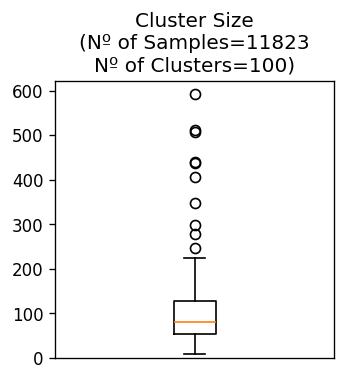

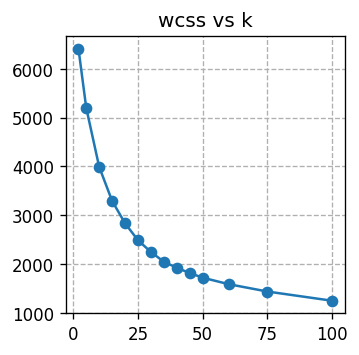

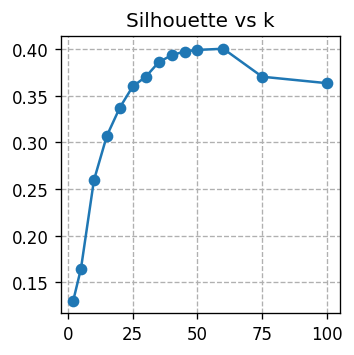

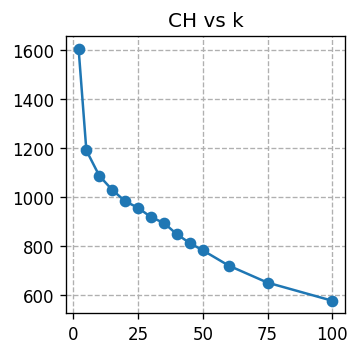

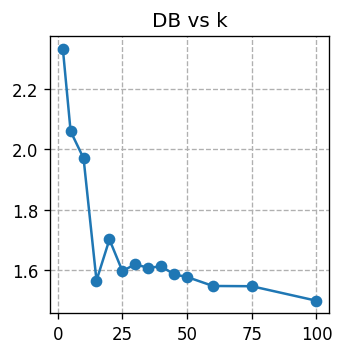

In [18]:
# imports
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# variables


# functions

def plot_nclusters(labels):
    _counts_labels = Counter(labels)
    plt.figure(figsize=(3,3), dpi=120)
    plt.title(f"Cluster Size\n(Nº of Samples={len(e_train)}\nNº of Clusters={len(_counts_labels)})")
    plt.boxplot(list(_counts_labels.values()))
    plt.ylim(0,)
    plt.xticks([])


def plot_clust_metric(df:pd.DataFrame, metric:str)->None:
    y = df[metric].to_list()
    x = df["k"].to_list()
    plt.figure(figsize=(3,3), dpi=120)
    plt.title(f"{metric} vs k")
    plt.plot(x,y,marker="o", zorder=3)
    plt.grid(linestyle="--", zorder=-3)
    plt.show()

def plot_reduced_emb(emb, labels, title):
    # Plot colored by cluster labels
    plt.figure(figsize=(6, 5))
    plt.scatter(
        emb[:, 0], 
        emb[:, 1], 
        c=labels, 
        cmap="gist_rainbow", 
        s=20
    )
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_clust_dis_perf(df:pd.DataFrame, metric:str, random:bool=False)->None:
    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]
    plt.figure(figsize=(3,3), dpi=120)
    for i, ic in enumerate([1.0, 0.8, 0.6, 0.396]):
        _df = df.query("ic_thr == @ic")
            
        plt.plot(
            _df["k"].to_list(),
            _df[metric].to_list(),
            label="Same" if ic ==1.0 else f"Related (+{ic})",
            color=colors[i],
            marker = ".",
            # linewidth=2.5
            zorder=3
        )
        if random:
            plt.axhline(_df["random"].values[0], linestyle="--", color=colors[i])
    plt.legend()
    plt.ylim(0,1)
    plt.title(f"{metric} vs Ks")
    plt.grid(linestyle="--", zorder=-3)
    plt.show()
def plot_stacked_p1(df: pd.DataFrame, metric: str = "precision1"):

    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]  # same → related
    # Sort IC thresholds so 1.0 (same disease) appears first in stacks
    ic_values = [1.0, 0.8, 0.6, 0.396]
    ks = sorted(df["k"].unique())

    x = np.arange(len(ks))
    bottom = np.zeros(len(ks))
    plt.figure(figsize=(10, 6))
    for i, ic in enumerate(ic_values):
        _df = df.query("ic_thr == @ic")
        vals = _df[metric].to_list() 
        vals = vals-bottom
        label = "Same disease" if ic == 1.0 else f"Related (+{ic})"
        
        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[i],
            label=label,
            edgecolor="black",
            linewidth=0.8, 
            zorder=1
        )
        bottom += vals


    plt.xticks(x, ks)
    plt.xlabel("k")
    plt.ylabel("Precision@1")
    plt.title("Stacked Precision@1 by Relatedness Level")
    plt.legend()
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=3)

    plt.show()


# plot nº of clusters
# plot_nclusters(km.labels_)

# plot cluster metrics
# plot_clust_metric(df_results,"NMI")
# plot_clust_metric(df_results,"ARI")
# plot_clust_metric(df_results,"AMI")
plot_clust_metric(df_results,"wcss")
plot_clust_metric(df_results,"Silhouette")
plot_clust_metric(df_results,"CH")
plot_clust_metric(df_results,"DB")


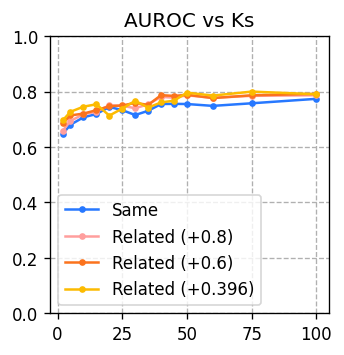

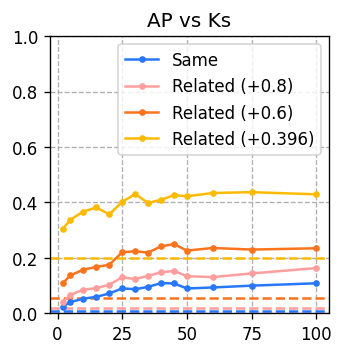

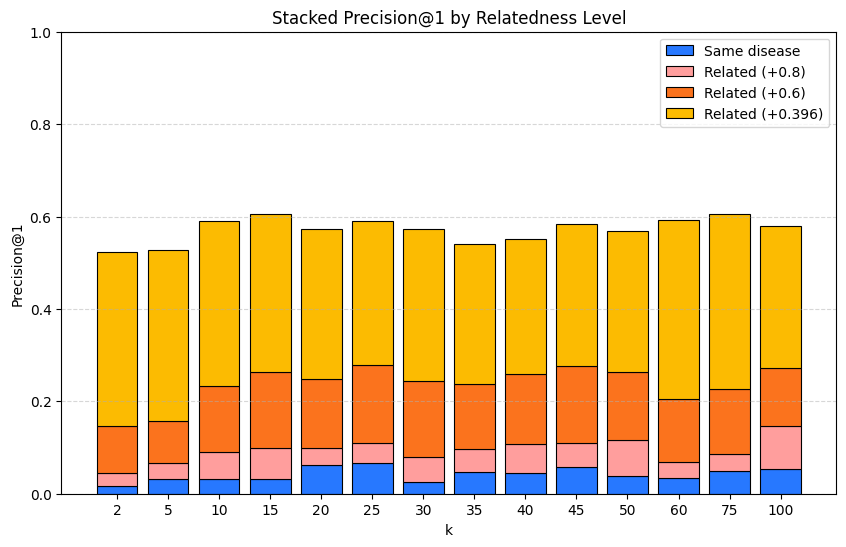

In [19]:
# plot performance
plot_clust_dis_perf(df_test_eval_all, "AUROC")
plot_clust_dis_perf(df_test_eval_all, "AP", random=True)
plot_stacked_p1(df_test_eval_all, metric="Prec@5")


In [ ]:

# Compute PCA
pca = PCA(n_components=2, random_state=42)
pca_emb = pca.fit_transform(e_train)   # shape: (n_samples, 2)

tsne = TSNE(n_components=2, random_state=42)
tsne_emb = tsne.fit_transform(e_train)

umap = UMAP(n_components=2, random_state=42)
umap_emb = umap.fit_transform(e_train)

plot_reduced_emb(pca_emb, km.labels_, title=f"PCA Disease Clusters\n(Nº Clusters={len(set(km.labels_))};Nº Samples={len(e_train)})")
plot_reduced_emb(tsne_emb, km.labels_, title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(km.labels_))};Nº Samples={len(e_train)})")
plot_reduced_emb(umap_emb, km.labels_, title=f"UMAP Disease Clusters\n(Nº Clusters={len(set(km.labels_))};Nº Samples={len(e_train)})")


### 3.1.2 Hierarchical Clustering

In [70]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

hc_metric = "cosine"
Z = linkage(pdist(e_train, metric=hc_metric), method="average")

_h_candidates = np.linspace(0.05, 0.5, 50)   # adjust range if needed
results = list()
i = 0
for h in tqdm(_h_candidates):   # <<< minimal change: iterate over thresholds
    
    # generate labels
    preds = fcluster(Z, t=h, criterion="distance") - 1  # remove 1 because f-cluster returns labels from 1-N
    k = len(np.unique(preds))

    if k == 1:
        break

    # evaluate
    _results_i = evaluate_clusters(preds, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "h": h})
    results.append(_results_i)

    # enrichment
    _df_enrich = run_hypergeom_enrichment(preds, df_train["doid_id"].astype(str).to_numpy())
    _df_enrich = _df_enrich.copy()
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    clust_to_dis = {}
    for cid in np.unique(_df_enrich_sig["cluster"]):
        diseases = _df_enrich_sig[_df_enrich_sig["cluster"] == cid]["disease"].to_list()
        clust_to_dis[int(cid)] = diseases

    # get centroids
    def get_clust_centroids(x, labels, label_ord):
        centroids = []
        for l in label_ord:
            centroid = x[labels == l].mean(axis=0)
            centroids.append(centroid)
        return np.array(centroids)

    clust_ord = np.sort(np.unique(preds))
    _centroids = get_clust_centroids(e_train, preds, clust_ord)

    # get similarity scores
    test_centr_sim = cosine_similarity(e_test, _centroids)

    test_scores = get_multilab_pred(
        test_centr_sim,
        clust_to_dis,
        dis_ord,
        clust_ord
    )

    test_scores = softmax(test_scores, axis=1)

    _df_test_eval = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    _df_test_eval.insert(0, "k", k)
    _df_test_eval.insert(1, "h", h)

    if i == 0:
        df_test_eval_all = _df_test_eval.copy()
        i += 1
    else:
        df_test_eval_all = pd.concat([df_test_eval_all, _df_test_eval], axis=0)

    

df_results = pd.DataFrame(results)


  0%|          | 0/50 [00:53<?, ?it/s]


In [69]:
best_k = 52

if best_k == None:
    df_test_eval_all.max()

df_k_best = df_test_eval_all.query("k==@best_k")

def get_df_results_clean(df, metrics):
    ics = {
        "Same": 1.0,
        "+.8": 0.8,
        "+.6": 0.6,
        "+.4": 0.396
    }
    out = {}
    for prefix, thr in ics.items():
        row = df.loc[df["ic_thr"] == thr].iloc[0]
        for m in metrics:
            if (thr == 1.0) & (m.startswith("Prec")):  
                m = m.replace("Prec", "Recall")
                out[f"{prefix} {m}"] = f"{row[m]:.3}"
            else:
                out[f"{prefix} {m}"] = f"{row[m]:.3}"

    return pd.DataFrame([out])

df_r_1 = get_df_results_clean(df_k_best, ["AUROC", "AP", "random"])
df_r_2 = get_df_results_clean(df_k_best, ["Prec@1", "Prec@3", "Prec@5"])


IndexError: single positional indexer is out-of-bounds

In [46]:
#_df_q = df_test_eval_all.query("ic_thr == 1.0")
# _df_q.iloc[_df_q["AP"].idxmax()]["k"]

2191

#### Evaluation Plots

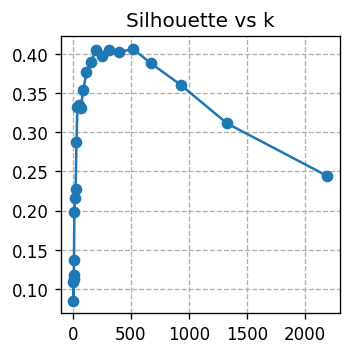

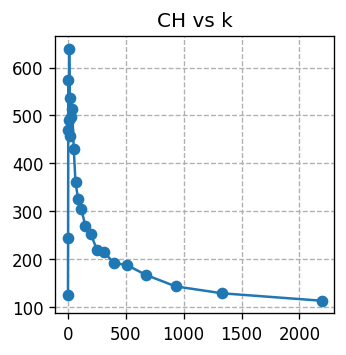

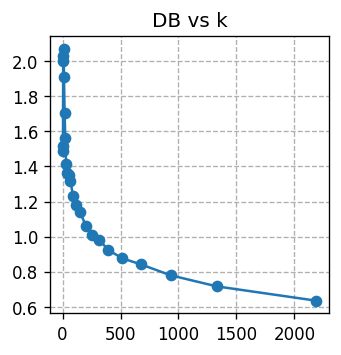

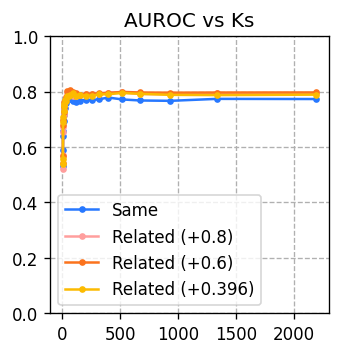

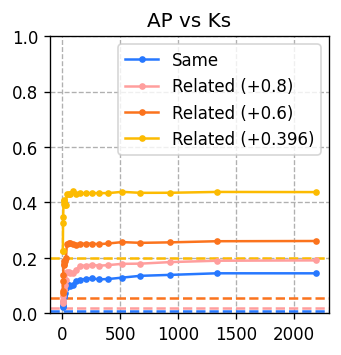

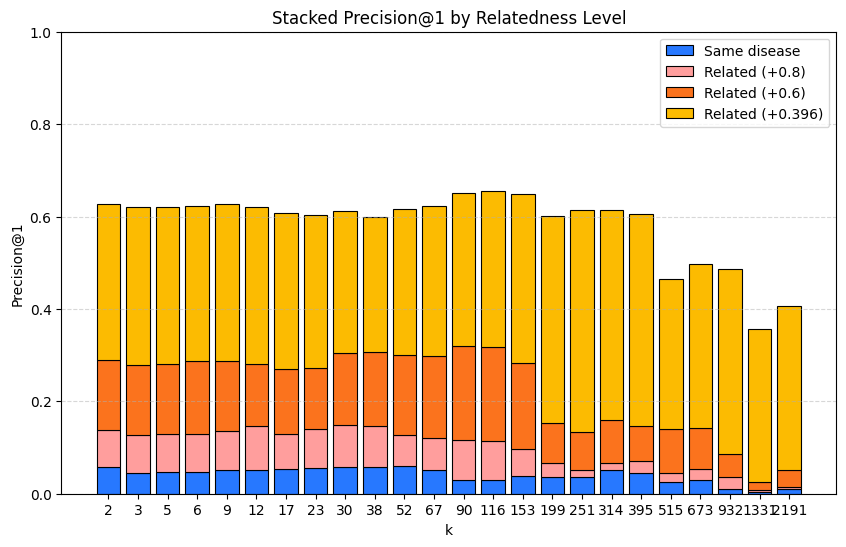

In [34]:
# plot_clust_metric(df_results,"wcss")
plot_clust_metric(df_results,"Silhouette")
plot_clust_metric(df_results,"CH")
plot_clust_metric(df_results,"DB")

# plot performance
plot_clust_dis_perf(df_test_eval_all, "AUROC")
plot_clust_dis_perf(df_test_eval_all, "AP", random=True)
plot_stacked_p1(df_test_eval_all, metric="Prec@5")


In [ ]:
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram

# exploratory plots - dendrogram
plt.figure(figsize=(12,6))
dendrogram(Z, labels=["" for _ in range(len(df_train))])
plt.show()


In [ ]:

# Compute PCA
pca = PCA(n_components=2, random_state=42)
pca_emb = pca.fit_transform(e_train)   # shape: (n_samples, 2)

tsne = TSNE(n_components=2, random_state=42)
tsne_emb = tsne.fit_transform(e_train)

umap = UMAP(n_components=2, random_state=42)
umap_emb = umap.fit_transform(e_train)

plot_reduced_emb(pca_emb, km.labels_, title=f"PCA Disease Clusters\n(Nº Clusters={len(set(km.labels_))};Nº Samples={len(e_train)})")
plot_reduced_emb(tsne_emb, km.labels_, title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(km.labels_))};Nº Samples={len(e_train)})")
plot_reduced_emb(umap_emb, km.labels_, title=f"UMAP Disease Clusters\n(Nº Clusters={len(set(km.labels_))};Nº Samples={len(e_train)})")


### HDBSCAN

### 3.1.3 Evaluate Performance

# Junkyard

In [ ]:
# imports
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# variables


# functions
def elbow_analysis(embs, k_min=2, k_max=20):
    Ks = list(range(k_min, k_max + 1))
    wcss = []

    for k in Ks:
        km = KMeans(n_clusters=k, n_init=20, random_state=42)
        km.fit(embs)
        wcss.append(km.inertia_)   # inertia = WCSS

    plt.figure(figsize=(8, 5))
    plt.plot(Ks, wcss, marker='o')
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Within-cluster sum of squares (WCSS)")
    plt.title("Elbow Analysis for Optimal K")
    plt.xticks(Ks)
    plt.grid(True)
    plt.show()

    return Ks, wcss


In [ ]:
from scipy.stats import fisher_exact
def run_hypergeom_enrichment(clusters, labels):
    """
    clusters: np.array of cluster assignments (ints or strings)
    labels:   np.array of disease labels (strings recommended)
    """

    # Ensure everything is string for safety
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)  # total samples

    unique_clusters = np.unique(clusters)
    unique_diseases = np.unique(labels)

    results = []

    for cluster_id in unique_clusters:
        cluster_mask = (clusters == cluster_id)
        n = np.sum(cluster_mask)  # cluster size

        for disease in unique_diseases:
            K = np.sum(labels == disease)               # total disease count in dataset
            k = np.sum((labels == disease) & cluster_mask)  # disease count in cluster

            if k == 0:
                continue  # no enrichment possible

            # Hypergeometric test (enrichment = P(X >= k))
            pval = hypergeom.sf(k - 1, N, K, n)

            results.append({
                "cluster": int(cluster_id),
                "disease": disease,
                "k_in_cluster": k,
                "K_total": K,
                "cluster_size": n,
                "total_N": N,
                "p_value": pval
            })

    # Return as DataFrame sorted by p-value (more enriched = smaller p)
    df = pd.DataFrame(results)
    df = df.sort_values(["cluster", "p_value"])

    return df

def run_full_enrichment(clusters, labels):
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)
    unique_clusters = np.unique(clusters)
    unique_dis = np.unique(labels)

    rows = []

    for c in unique_clusters:
        c_mask = (clusters == c)
        n = c_mask.sum()

        for d in unique_dis:
            K = (labels == d).sum()
            k = ((labels == d) & c_mask).sum()
            if k == 0:
                continue

            # hypergeometric
            hypergeom_p = hypergeom.sf(k - 1, N, K, n)

            # contingency table
            a = k
            b = n - k
            c2 = K - k
            d = (N - n) - c2
            or_val, fisher_p = fisher_exact([[a, b], [c2, d]])

            # fold enrichment
            fe = (k / n) / (K / N)
            log2fe = np.log2(fe + 1e-12)

            rows.append({
                "cluster": c,
                "disease": d,
                "k": k,
                "n": n,
                "K": K,
                "N": N,
                "hypergeom_p": hypergeom_p,
                "odds_ratio": or_val,
                "fisher_p": fisher_p,
                "fold_enrichment": fe,
                "log2_fold_enrichment": log2fe
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["cluster", "hypergeom_p"])
    return df
 

_df_enrich = run_hypergeom_enrichment(km.labels_, df_train["doid_id"].astype(str).to_numpy())
_df_enrich_full = run_full_enrichment(km.labels_, df_train["doid_id"].astype(str).to_numpy())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix,
    normalized_mutual_info_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA
import umap

def cluster_purity(true_labels, cluster_labels):
    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def evaluate_kmeans_across_K(
    embs,
    labels=None,
    K_range=range(2, 21),
    use_umap=False
):

    WCSS = []
    Sil = []
    CH = []
    DB = []

    Purity = []
    NMI = []
    ARI = []
    AMI = []

    cluster_assignments = {}

    for K in K_range:
        km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(embs)
        preds = km.labels_
        cluster_assignments[K] = preds

        # Core clustering metric
        WCSS.append(km.inertia_)

        # Geometry metrics
        Sil.append(silhouette_score(embs, preds))
        CH.append(calinski_harabasz_score(embs, preds))
        DB.append(davies_bouldin_score(embs, preds))

        if labels is not None:
            Purity.append(cluster_purity(labels, preds))
            NMI.append(normalized_mutual_info_score(labels, preds))
            ARI.append(adjusted_rand_score(labels, preds))
            AMI.append(adjusted_mutual_info_score(labels, preds))

    return {
        "WCSS": WCSS,
        "Silhouette": Sil,
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
        "clusters": cluster_assignments,
        "K_range": list(K_range),
    }



def plot_cluster_diagnostics(results, labels_available=True):

    Ks = results["K_range"]

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["WCSS"], marker='o')
    plt.title("Elbow Curve (WCSS)")
    plt.xlabel("K")
    plt.ylabel("WCSS")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["Silhouette"], marker='o')
    plt.title("Silhouette Score vs K")
    plt.xlabel("K")
    plt.ylabel("Silhouette")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["CH"], marker='o')
    plt.title("Calinski–Harabasz Index vs K")
    plt.xlabel("K")
    plt.ylabel("CH Index")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["DB"], marker='o')
    plt.title("Davies–Bouldin Index vs K")
    plt.xlabel("K")
    plt.ylabel("DB Index (lower better)")
    plt.grid(True)
    plt.show()

    if labels_available:
        plt.figure(figsize=(7,5))
        plt.plot(Ks, results["Purity"], marker='o')
        plt.title("Purity vs K")
        plt.xlabel("K")
        plt.ylabel("Purity")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(7,5))
        plt.plot(Ks, results["NMI"], marker='o', label="NMI")
        plt.plot(Ks, results["ARI"], marker='o', label="ARI")
        plt.plot(Ks, results["AMI"], marker='o', label="AMI")
        plt.title("Agreement Metrics vs K")
        plt.xlabel("K")
        plt.ylabel("Score (0–1)")
        plt.legend()
        plt.grid(True)
        plt.show()


def plot_clusters_in_latent(embs, cluster_labels, method="umap"):
    if method == "umap":
        reducer = umap.UMAP(random_state=42)
        X2 = reducer.fit_transform(embs)
        title = "UMAP Projection"
    else:
        reducer = PCA(n_components=2)
        X2 = reducer.fit_transform(embs)
        title = "PCA Projection"

    plt.figure(figsize=(7,6))
    plt.scatter(X2[:,0], X2[:,1], c=cluster_labels, cmap="tab20", s=10)
    plt.title(f"{title} Colored by Cluster")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()



# Step 1: Run KMeans across K range
results = evaluate_kmeans_across_K(
    embeddings_train, 
    labels=df_train["doid_id"].astype(str).to_list(), 
    K_range=range(30, 31)
)

# Step 2: Plot all diagnostic curves
plot_cluster_diagnostics(results, labels_available=(df_train["doid_id"].astype(str).to_list() is not None))

# Step 3: Pick K manually (from elbow/silhouette/etc)
best_K = 30   # example

# Step 4: Visualize clusters
best_clusters = results["clusters"][best_K]
plot_clusters_in_latent(embeddings_train, best_clusters, method="umap")
plot_clusters_in_latent(embeddings_train, best_clusters, method="pca")


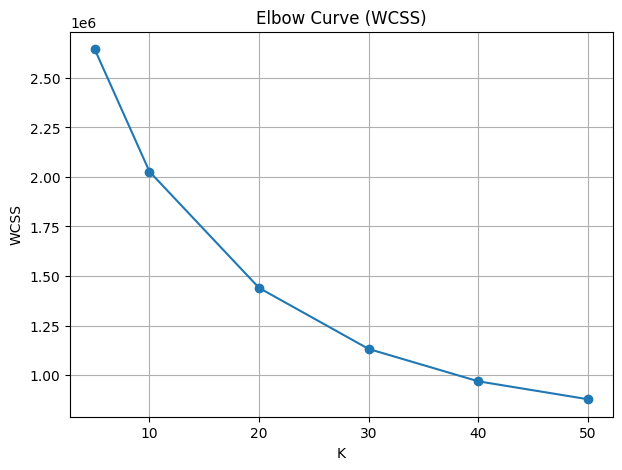

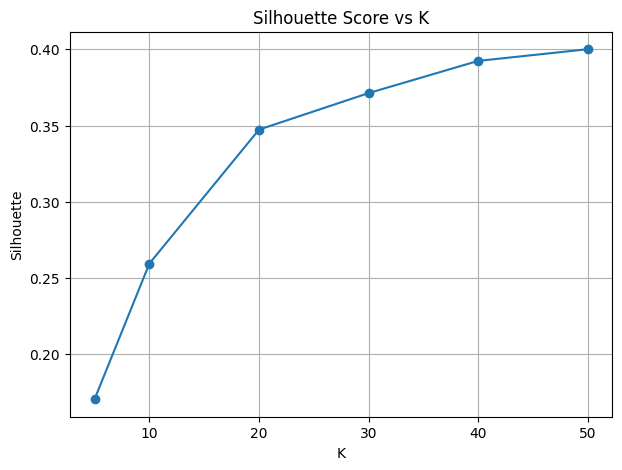

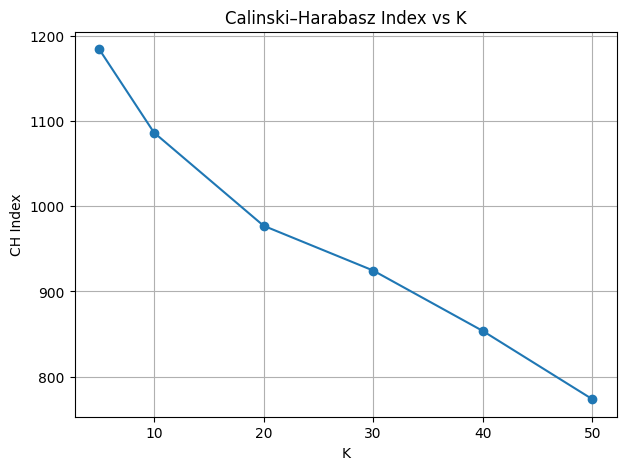

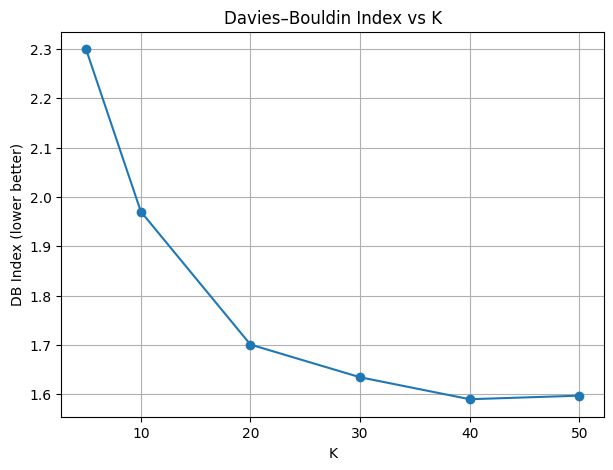

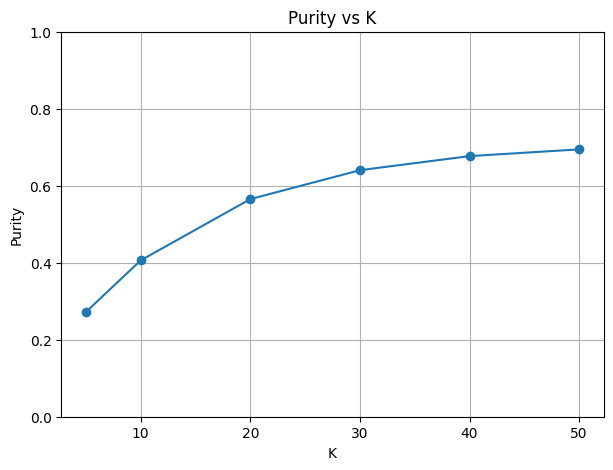

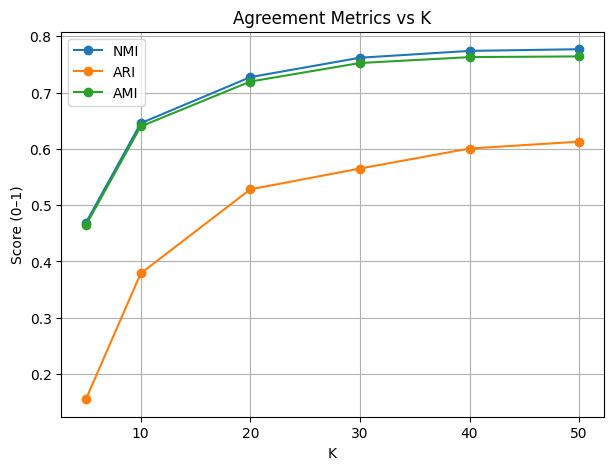

/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


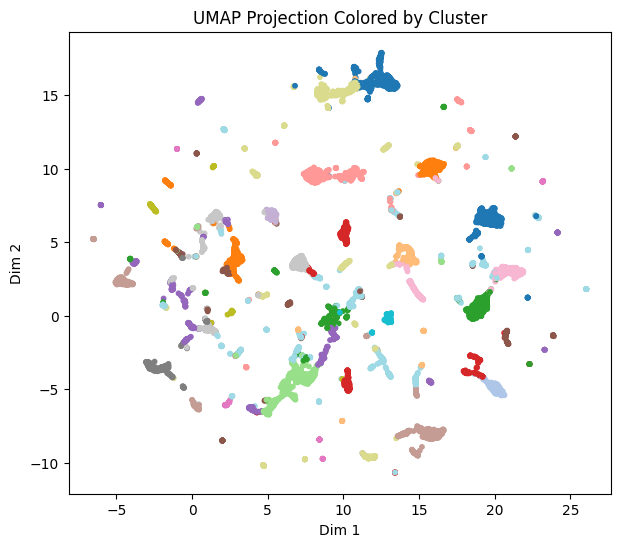

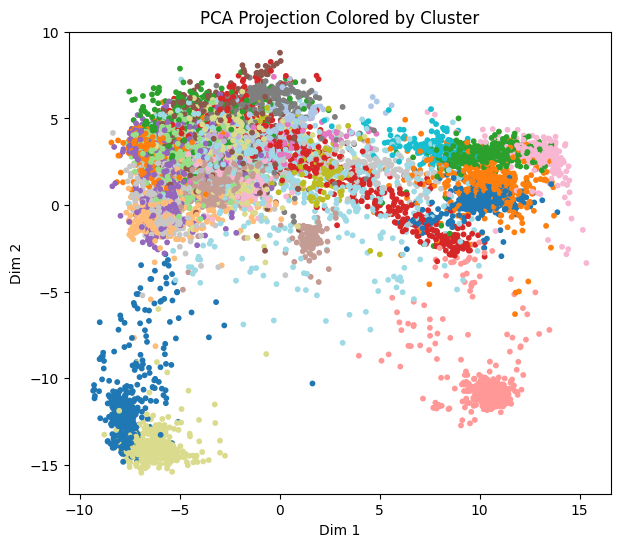

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix,
    normalized_mutual_info_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA
import umap

# -------------------------------
# FIXED PURITY FUNCTION
# -------------------------------
def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

# -------------------------------
# FIXED EVALUATION LOOP
# -------------------------------
def evaluate_kmeans_across_K(
    embs,
    labels=None,
    K_range=range(2, 21),
):

    # Convert true labels once here
    if labels is not None:
        labels = np.array(labels).astype(str)

    WCSS, Sil, CH, DB = [], [], [], []
    Purity, NMI, ARI, AMI = [], [], [], []

    cluster_assignments = {}

    for K in K_range:
        km = KMeans(n_clusters=K, n_init=20, random_state=42).fit(embs)
        preds = km.labels_.astype(str)   # <-- FIX: convert preds to string ALWAYS
        cluster_assignments[K] = preds

        # Core clustering metric
        WCSS.append(km.inertia_)

        # Geometry metrics
        Sil.append(silhouette_score(embs, preds.astype(int)))  # silhouette requires integers
        CH.append(calinski_harabasz_score(embs, preds.astype(int)))
        DB.append(davies_bouldin_score(embs, preds.astype(int)))

        # Label-based metrics
        if labels is not None:
            Purity.append(cluster_purity(labels, preds))
            NMI.append(normalized_mutual_info_score(labels, preds))
            ARI.append(adjusted_rand_score(labels, preds))
            AMI.append(adjusted_mutual_info_score(labels, preds))

    return {
        "WCSS": WCSS,
        "Silhouette": Sil,
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
        "clusters": cluster_assignments,
        "K_range": list(K_range),
    }

# -------------------------------
# PLOT DIAGNOSTICS
# -------------------------------
def plot_cluster_diagnostics(results, labels_available=True):

    Ks = results["K_range"]

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["WCSS"], marker='o')
    plt.title("Elbow Curve (WCSS)")
    plt.xlabel("K")
    plt.ylabel("WCSS")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["Silhouette"], marker='o')
    plt.title("Silhouette Score vs K")
    plt.xlabel("K")
    plt.ylabel("Silhouette")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["CH"], marker='o')
    plt.title("Calinski–Harabasz Index vs K")
    plt.xlabel("K")
    plt.ylabel("CH Index")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(Ks, results["DB"], marker='o')
    plt.title("Davies–Bouldin Index vs K")
    plt.xlabel("K")
    plt.ylabel("DB Index (lower better)")
    plt.grid(True)
    plt.show()

    if labels_available:
        plt.figure(figsize=(7,5))
        plt.plot(Ks, results["Purity"], marker='o')
        plt.title("Purity vs K")
        plt.xlabel("K")
        plt.ylabel("Purity")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(7,5))
        plt.plot(Ks, results["NMI"], marker='o', label="NMI")
        plt.plot(Ks, results["ARI"], marker='o', label="ARI")
        plt.plot(Ks, results["AMI"], marker='o', label="AMI")
        plt.title("Agreement Metrics vs K")
        plt.xlabel("K")
        plt.ylabel("Score (0–1)")
        plt.legend()
        plt.grid(True)
        plt.show()

# -------------------------------
# LATENT SPACE VISUALIZATION
# -------------------------------
def plot_clusters_in_latent(embs, cluster_labels, method="umap"):
    if method == "umap":
        reducer = umap.UMAP(random_state=42)
        X2 = reducer.fit_transform(embs)
        title = "UMAP Projection"
    else:
        reducer = PCA(n_components=2)
        X2 = reducer.fit_transform(embs)
        title = "PCA Projection"

    plt.figure(figsize=(7,6))
    plt.scatter(X2[:,0], X2[:,1], c=cluster_labels.astype(int), cmap="tab20", s=10)
    plt.title(f"{title} Colored by Cluster")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

# -------------------------------
# RUN PIPELINE
# -------------------------------
results = evaluate_kmeans_across_K(
    e_train,
    labels=df_train["doid_id"].astype(str).to_list(),
    K_range=[5, 10, 20, 30, 40, 50]
)

plot_cluster_diagnostics(
    results,
    labels_available=True
)

best_K = 30
best_clusters = results["clusters"][best_K]

plot_clusters_in_latent(e_train, best_clusters, method="umap")
plot_clusters_in_latent(e_train, best_clusters, method="pca")



In [20]:
# imports
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from scipy.special import softmax

# ============================================================
# NEW: Fold-enrichment function (replaces hypergeom)
# ============================================================
def run_fold_enrichment(clusters, labels, min_fold=1.05):
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)
    unique_clusters = np.unique(clusters)
    unique_diseases = np.unique(labels)

    # Total disease frequencies
    disease_counts = {d: np.sum(labels == d) for d in unique_diseases}

    rows = []

    for cid in unique_clusters:
        mask = clusters == cid
        n_c = mask.sum()

        for d in unique_diseases:
            K_d = disease_counts[d]
            k_cd = np.sum((labels == d) & mask)

            if k_cd == 0:
                continue

            # fold enrichment
            fold = (k_cd / n_c) / (K_d / N)

            if fold >= min_fold:
                rows.append({
                    "cluster": int(cid),
                    "disease": d,
                    "fold": fold,
                    "k_cd": k_cd,
                    "cluster_size": n_c,
                    "K_d": K_d,
                    "N": N
                })

    df = pd.DataFrame(rows)
    return df.sort_values(["cluster", "fold"], ascending=[True, False])


# ============================================================
# NEW: Weighted multilabel prediction using fold enrichment
# ============================================================
def get_multilab_pred_fold(cluster_scores, clust_to_dis_w, dis_ord, clust_ord):
    """
    cluster_scores: cosine similarities (N_samples × K_clusters)
    clust_to_dis_w: {cluster: {disease: fold_weight}}
    """
    n_samples, n_clusters = cluster_scores.shape
    n_diseases = len(dis_ord)

    dis_to_idx = {d: i for i, d in enumerate(dis_ord)}

    y_pred = np.zeros((n_samples, n_diseases))

    for i in range(n_samples):
        for c in clust_ord:
            score_c = cluster_scores[i, c]
            mapping = clust_to_dis_w.get(c, {})  # {disease: fold}

            for d, fold in mapping.items():
                idx = dis_to_idx.get(d)
                if idx is None:
                    continue

                weighted_score = score_c + 0.1* fold
                y_pred[i, idx] = max(y_pred[i, idx], weighted_score)

    return y_pred


# ============================================================
# Your original functions (unchanged)
# ============================================================
def cluster_purity(true_labels, cluster_labels):
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)
    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def evaluate_clusters(preds, labels, embs):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

    if labels is not None:
        labels = np.array(labels).astype(str)

    Sil = silhouette_score(embs, preds.astype(int))
    CH = calinski_harabasz_score(embs, preds.astype(int))
    DB = davies_bouldin_score(embs, preds.astype(int))

    Purity = cluster_purity(labels, preds)
    NMI = normalized_mutual_info_score(labels, preds)
    ARI = adjusted_rand_score(labels, preds)
    AMI = adjusted_mutual_info_score(labels, preds)

    return {
        "Silhouette": Sil,
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
    }


# (Keeping all your metric and eval functions unchanged...)
# ============================================================

# define disease order
dis_ord = df_train["doid_id"].unique().to_list()

results = []
i = 0
for k in tqdm(_k_candidates):

    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing
        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)

    _wcss = km.inertia_
    _results_i = evaluate_clusters(km.labels_, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "wcss": _wcss})
    results.append(_results_i)

    # ============================================================
    # NEW: Use fold enrichment instead of hypergeometric
    # ============================================================
    df_enrich = run_fold_enrichment(
        km.labels_,
        df_train["doid_id"].astype(str).values,
        min_fold=1.05
    )

    # Build weighted map: cluster → {disease: fold_weight}
    clust_to_dis_w = {}
    for cid in df_enrich["cluster"].unique():
        sub = df_enrich[df_enrich["cluster"] == cid]
        clust_to_dis_w[cid] = dict(zip(sub["disease"], sub["fold"]))

    # ============================================================
    # Cluster centroids (unchanged)
    # ============================================================
    def get_clust_centroids(x, labels, label_ord):
        centroids = []
        for l in label_ord:
            points = x[labels == l]
            centroids.append(points.mean(axis=0))
        return np.array(centroids)

    clust_ord = np.sort(np.unique(km.labels_))
    _centroids = get_clust_centroids(e_train, km.labels_, clust_ord)

    # ============================================================
    # Compute cosine similarity (cluster scores)
    # ============================================================
    test_centr_sim = cosine_similarity(e_test, _centroids)

    # ============================================================
    # NEW multilabel prediction using fold enrichment
    # ============================================================
    test_scores = get_multilab_pred_fold(
        test_centr_sim,
        clust_to_dis_w,
        dis_ord,
        clust_ord
    )

    # ============================================================
    # Normalize scores back to [0,1] (softmax per row)
    # ============================================================
    test_scores = softmax(test_scores, axis=1)

    # ============================================================
    # Evaluate
    # ============================================================
    _df_test_eval = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    _df_test_eval.insert(0, "k", k)

    if i == 0:
        df_test_eval_all = _df_test_eval.copy()
        i += 1
    else:
        df_test_eval_all = pd.concat([df_test_eval_all, _df_test_eval], axis=0)

df_results = pd.DataFrame(results)


/tmp/ipykernel_35459/3463831405.py:132: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  dis_ord = df_train["doid_id"].unique().to_list()
100%|██████████| 7/7 [01:18<00:00, 11.24s/it]


In [21]:
df_test_eval_all

,k,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,2,1.000,0.655645,0.025142,0.008130,0.002769,0.024001,0.016117,0.002769,0.072002,0.080587,0.011654,0.204376,21.18637496538355±25.369403578976858
1,2,0.800,0.672930,0.042082,0.019054,0.002769,0.032124,0.021379,0.002769,0.033929,0.038152,0.015454,0.169925,21.18637496538355±25.369403578976858
2,2,0.600,0.703965,0.120780,0.054900,0.008862,0.172344,0.130435,0.002548,0.071760,0.084893,0.163089,0.289436,21.18637496538355±25.369403578976858
3,2,0.396,0.718233,0.330344,0.199877,0.562171,0.594849,0.587815,0.017304,0.059887,0.097600,0.583413,0.283769,21.18637496538355±25.369403578976858
0,5,1.000,0.692567,0.042147,0.008130,0.005539,0.006185,0.026364,0.005539,0.018554,0.131819,0.005539,0.005539,1.0±0.0
1,5,0.800,0.709069,0.069014,0.019054,0.007200,0.008308,0.032567,0.003323,0.017308,0.090243,0.007200,0.003323,1.0±0.0
2,5,0.600,0.720984,0.142111,0.054900,0.011354,0.119173,0.233896,0.002669,0.041115,0.141470,0.011354,0.002669,1.0±0.0
3,5,0.396,0.734060,0.348032,0.199877,0.599280,0.600757,0.567377,0.018196,0.055126,0.088838,0.599280,0.018196,1.0±0.0
0,10,1.000,0.723972,0.067982,0.008130,0.004985,0.006739,0.006868,0.004985,0.020216,0.034340,0.004985,0.004985,1.0±0.0
1,10,0.800,0.725186,0.090197,0.019054,0.008862,0.009693,0.009305,0.004431,0.020216,0.032401,0.008862,0.004431,1.0±0.0


In [19]:
df_test_eval_all

,k,ic_thr,AUROC,AP,random,Prec@1,Prec@3,Prec@5,Recall@1,Recall@3,Recall@5,Prec@TopClust,Recall@TopClust,Size@TopClust
0,2,1.000,0.674681,0.023857,0.008130,0.001385,0.022801,0.015397,0.001385,0.068402,0.076987,0.011297,0.092772,8.32594849072279±1.3661410444035043
1,2,0.800,0.684052,0.038681,0.019054,0.001385,0.029170,0.021102,0.001385,0.029059,0.034598,0.015109,0.050106,8.32594849072279±1.3661410444035043
2,2,0.600,0.707773,0.111034,0.054900,0.007477,0.160620,0.118859,0.001302,0.053298,0.065028,0.150621,0.133939,8.32594849072279±1.3661410444035043
3,2,0.396,0.718335,0.316990,0.199877,0.576295,0.578879,0.576849,0.016791,0.051870,0.085936,0.575051,0.140539,8.32594849072279±1.3661410444035043
0,5,1.000,0.713304,0.034433,0.008130,0.009139,0.012000,0.028081,0.009139,0.036001,0.140404,0.009139,0.009139,1.0±0.0
1,5,0.800,0.704549,0.048815,0.019054,0.013293,0.016893,0.035170,0.006785,0.033970,0.097434,0.013293,0.006785,1.0±0.0
2,5,0.600,0.687720,0.091888,0.054900,0.036278,0.140220,0.199225,0.006359,0.057636,0.126362,0.036278,0.006359,1.0±0.0
3,5,0.396,0.603482,0.221699,0.199877,0.609526,0.615527,0.579895,0.019181,0.059118,0.094537,0.609526,0.019181,1.0±0.0
0,10,1.000,0.747236,0.045785,0.008130,0.012462,0.015047,0.011299,0.012462,0.045140,0.056494,0.013847,0.018001,1.0714483522569924±0.32676520394538633
1,10,0.800,0.735691,0.067822,0.019054,0.016339,0.020031,0.015231,0.011908,0.043755,0.054796,0.018416,0.018139,1.0714483522569924±0.32676520394538633


In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster

hc_metric = "cosine"
Z = linkage(pdist(e_train, metric=hc_metric), method="average")


# _h_candidates = np.linspace(0.05, 1.5, 50)   # adjust range if needed
_h_candidates = [0.1, 0.3, 0.5, 0.6]   # adjust range if needed


results = []
i = 0

# LOOP OVER HIERARCHICAL HEIGHT THRESHOLDS
for h in tqdm(_h_candidates):

    # 1) Compute clusters at height h
    clusters = fcluster(Z, t=h, criterion="distance")  # array of shape (N,)
    n_clusters = len(np.unique(clusters))

    # Skip degenerate cases
    if n_clusters < 2:
        continue

    # 2) Evaluate cluster geometry & supervised metrics
    _results_i = evaluate_clusters(clusters, df_train["doid_id"].values, e_train)
    _results_i.update({"height": h, "n_clusters": n_clusters})
    results.append(_results_i)

    # 3) Enrichment analysis (unchanged)
    _df_enrich = run_hypergeom_enrichment(clusters, df_train["doid_id"].astype(str).to_numpy())
    _df_enrich = _df_enrich.copy()
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    # cluster → diseases mapping
    clust_to_dis = {}
    for cid in np.unique(_df_enrich_sig["cluster"]):
        diseases = _df_enrich_sig.loc[_df_enrich_sig["cluster"] == cid, "disease"].to_list()
        clust_to_dis[int(cid)] = diseases

    # 4) Compute centroids for this clustering
    def get_clust_centroids(x, labels, label_ord):
        out = []
        for l in label_ord:
            pts = x[labels == l]
            out.append(pts.mean(axis=0))
        return np.array(out)

    cluster_ids = np.sort(np.unique(clusters))
    centroids = get_clust_centroids(e_train, clusters, cluster_ids)

    # 5) Similarity of test samples to centroids
    test_centr_sim = cosine_similarity(e_test, centroids)

    # 6) Multilabel predictions from similarity + enrichment
    test_scores = get_multilab_pred(
        test_centr_sim,
        clust_to_dis,
        dis_ord,
        cluster_ids-1
    )

    # 7) Evaluate multilabel predictions
    _df_test_eval = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1,3,5]
    )
    _df_test_eval.insert(0, "height", h)
    _df_test_eval.insert(1, "n_clusters", n_clusters)

    if i == 0:
        df_test_eval_all = _df_test_eval.copy()
        i += 1
    else:
        df_test_eval_all = pd.concat([df_test_eval_all, _df_test_eval], axis=0)


In [ ]:
# import numpy as np
# from scipy.cluster.hierarchy import linkage, dendrogram
# import matplotlib.pyplot as plt

# # embeddings: numpy array (N_nodes, latent_dim)
# # labels: list of names (e.g., DOIDs or disease names)

# def hierarchical_clustering(embeddings, labels=None, method="ward"):
#     """
#     embeddings: 2D array (N, dim)
#     labels: list of strings of length N
#     method: 'ward', 'average', 'complete', 'single'

#     returns: scipy linkage matrix
#     """
#     Z = linkage(embeddings, method=method)

#     plt.figure(figsize=(12, 6))
#     dendrogram(Z, labels=labels, leaf_rotation=90, leaf_font_size=8)
#     plt.title(f"Hierarchical Clustering ({method} linkage)")
#     plt.tight_layout()
#     plt.show()

#     return Z

# Z = hierarchical_clustering(e_train, labels=df_train["doid_id"].astype(str).to_numpy(), method="ward")


In [ ]:
# imports
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# variables
hc_metric = "cosine"
hc_criterion = "distance"
assert hc_criterion in ["maxclust", "distance"], "Invalid hc_criterion"

# hc_h_thr = 10   # HC Height Threshold
# hc_k_thr = 20   # HC Max Clusters Threshold

# functions
def get_sil_scores(Z:np.array, e_train:np.array, candidate_thrs:np.array, hc_criterion:str,  metric:str)->np.array:
    sil_scores = []
    for h in candidate_thrs:
        labels = fcluster(Z, t=h, criterion=hc_criterion)
        if len(np.unique(labels)) < 2:  # silhouette undefined if only 1 cluster
            sil_scores.append(-1)
            continue
        score = silhouette_score(e_train, labels, metric=metric)
        sil_scores.append(score)
    return np.array(sil_scores)

def plot_sil_thr(x:np.array, y:np.array, best_thr:int, best_sil:int, cluster_type:str)->None: 
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker='o', linewidth=2, markersize=5)
    plt.axvline(best_thr, color='red', linestyle='--', linewidth=1.5, label=f"Best thr. = {best_thr:.3f}")
    plt.scatter([best_thr], [best_sil], color='red', s=80, zorder=5)

    plt.title(f"Silhouette Score vs {cluster_type}")
    plt.xlabel(f"Cut {cluster_type}")
    plt.ylabel("Silhouette Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# distance matrix
dist_matrix = pdist(e_train, metric=hc_metric)

# hierarchical clustering
Z = linkage(dist_matrix, method="average")

# get candidate thresholds
if hc_criterion == "distance":
    _cand_thrs = np.linspace(0.01, 0.5, 50)
elif hc_criterion == "maxclust":
    max_clusters = max(150, int(np.sqrt(len(e_train))) * 10)
    _cand_thrs = np.arange(2, max_clusters + 1, 10)

# get silhouette scores
sil_scores = get_sil_scores(Z, e_train, _cand_thrs, hc_criterion, hc_metric)

# get best threshold
best_idx = np.argmax(sil_scores)
best_thr = _cand_thrs[best_idx]
best_sil = sil_scores[best_idx]
print(f"Best HC threshold for {hc_criterion}: {best_thr:.3f} with Silhouette Score: {best_sil:.4f}")

# plot silhouette vs threshold
plot_sil_thr(_cand_thrs, sil_scores, best_thr, best_sil, cluster_type=hc_criterion)

if hc_criterion == "maxclust":
    _cand_thrs = np.arange(max(2, best_thr-20), best_thr+21, 1)
    sil_scores = get_sil_scores(Z, e_train, _cand_thrs, hc_criterion, hc_metric)
    best_idx = np.argmax(sil_scores)
    best_thr = _cand_thrs[best_idx]
    best_sil = sil_scores[best_idx]
    print(f"Best HC threshold for {hc_criterion}: {best_thr:.3f} with Silhouette Score: {best_sil:.4f}")

    # plot silhouette vs threshold
    plot_sil_thr(_cand_thrs, sil_scores, best_thr, best_sil, cluster_type=hc_criterion)


In [ ]:
# imports
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# variables
hc_metric = "cosine"
hc_criterion = "distance"
assert hc_criterion in ["maxclust", "distance"], "Invalid hc_criterion"

# hc_h_thr = 10   # HC Height Threshold
# hc_k_thr = 20   # HC Max Clusters Threshold

# functions
def get_sil_scores(Z:np.array, e_train:np.array, candidate_thrs:np.array, hc_criterion:str,  metric:str)->np.array:
    sil_scores = []
    for h in candidate_thrs:
        labels = fcluster(Z, t=h, criterion=hc_criterion)
        if len(np.unique(labels)) < 2:  # silhouette undefined if only 1 cluster
            sil_scores.append(-1)
            continue
        score = silhouette_score(e_train, labels, metric=metric)
        sil_scores.append(score)
    return np.array(sil_scores)

def plot_sil_thr(x:np.array, y:np.array, best_thr:int, best_sil:int, cluster_type:str)->None: 
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker='o', linewidth=2, markersize=5)
    plt.axvline(best_thr, color='red', linestyle='--', linewidth=1.5, label=f"Best thr. = {best_thr:.3f}")
    plt.scatter([best_thr], [best_sil], color='red', s=80, zorder=5)

    plt.title(f"Silhouette Score vs {cluster_type}")
    plt.xlabel(f"Cut {cluster_type}")
    plt.ylabel("Silhouette Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# distance matrix
dist_matrix = pdist(e_train, metric=hc_metric)

# hierarchical clustering
Z = linkage(dist_matrix, method="average")

# get candidate thresholds
if hc_criterion == "distance":
    _cand_thrs = np.linspace(0.01, 0.5, 50)
elif hc_criterion == "maxclust":
    max_clusters = max(150, int(np.sqrt(len(e_train))) * 10)
    _cand_thrs = np.arange(2, max_clusters + 1, 10)

# get silhouette scores
sil_scores = get_sil_scores(Z, e_train, _cand_thrs, hc_criterion, hc_metric)

# get best threshold
best_idx = np.argmax(sil_scores)
best_thr = _cand_thrs[best_idx]
best_sil = sil_scores[best_idx]
print(f"Best HC threshold for {hc_criterion}: {best_thr:.3f} with Silhouette Score: {best_sil:.4f}")

# plot silhouette vs threshold
plot_sil_thr(_cand_thrs, sil_scores, best_thr, best_sil, cluster_type=hc_criterion)

if hc_criterion == "maxclust":
    _cand_thrs = np.arange(max(2, best_thr-20), best_thr+21, 1)
    sil_scores = get_sil_scores(Z, e_train, _cand_thrs, hc_criterion, hc_metric)
    best_idx = np.argmax(sil_scores)
    best_thr = _cand_thrs[best_idx]
    best_sil = sil_scores[best_idx]
    print(f"Best HC threshold for {hc_criterion}: {best_thr:.3f} with Silhouette Score: {best_sil:.4f}")

    # plot silhouette vs threshold
    plot_sil_thr(_cand_thrs, sil_scores, best_thr, best_sil, cluster_type=hc_criterion)


In [ ]:
from scipy.cluster.hierarchy import fcluster
import numpy as np

# Z: linkage matrix from hierarchical clustering
cut_height = 0.35

cluster_labels = fcluster(Z, t=cut_height, criterion='distance')
# cluster_labels: shape (N_diseases,), ints: 1,2,3,...,K

n_clusters = len(np.unique(cluster_labels))
print("Number of clusters at height 0.15:", n_clusters)


In [ ]:
plot_reduced_emb(tsne_emb, cluster_labels, "")
plot_nclusters(cluster_labels)

In [ ]:

# embeddings: (N_diseases, dim)
# disease_ids: list/array of DOIDs or disease names length N_diseases
import pandas as pd

df_clusters = pd.DataFrame({
    "disease_id": disease_ids,
    "cluster": cluster_labels
})

# Quick look
print(df_clusters.head())


cluster_sizes = df_clusters["cluster"].value_counts().sort_index()
print(cluster_sizes)

# Example: view all diseases in cluster 3
df_clusters[df_clusters["cluster"] == 3]


In [ ]:
import hdbscan
# HDBSCAN parameter grid
_hdbscan_params = [
    {"min_cluster_size": 5, "min_samples": 1},
    {"min_cluster_size": 10, "min_samples": 1},
    {"min_cluster_size": 15, "min_samples": 1},
    {"min_cluster_size": 20, "min_samples": 5},
    {"min_cluster_size": 30, "min_samples": 10},
    {"min_cluster_size": 50, "min_samples": 10},
]

results = []
i = 0

for params in tqdm(_hdbscan_params):

    # 1) Run HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=params["min_cluster_size"],
        min_samples=params["min_samples"],
        metric="euclidean",  # You can change to "cosine"
        cluster_selection_epsilon=0.0,
        cluster_selection_method="eom"
    ).fit(e_train)

    clusters = clusterer.labels_                      # shape (N,)
    cluster_ids = np.unique(clusters[clusters >= 0])  # ignore noise
    n_clusters = len(cluster_ids)

    # Skip degenerate cases
    if n_clusters < 2:
        continue

    # Make cluster labels contiguous (0..K-1) while ignoring noise
    # -1 stays as noise and can be handled separately
    cluster_map = {cid: idx for idx, cid in enumerate(cluster_ids)}
    new_clusters = np.array([cluster_map[c] if c in cluster_map else -1 for c in clusters])

    # 2) Evaluate cluster geometry & label agreement (noise ignored)
    mask = new_clusters != -1
    _results_i = evaluate_clusters(new_clusters[mask], df_train["doid_id"].values[mask], e_train[mask])
    _results_i.update({
        "min_cluster_size": params["min_cluster_size"],
        "min_samples": params["min_samples"],
        "n_clusters": n_clusters
    })
    results.append(_results_i)

    # 3) Enrichment analysis (only for non-noise)
    _df_enrich = run_hypergeom_enrichment(new_clusters[mask], df_train["doid_id"].values[mask])
    _df_enrich["disease_name"] = _df_enrich["disease"].apply(lambda x: doid_to_term.get(x, "Control"))
    _df_enrich_sig = _df_enrich[_df_enrich["p_value"] < ALPHA]

    clust_to_dis = {}
    for cid in np.unique(_df_enrich_sig["cluster"]):
        diseases = _df_enrich_sig.loc[_df_enrich_sig["cluster"] == cid, "disease"].to_list()
        clust_to_dis[cid] = diseases

    # 4) Compute centroids for non-noise clusters
    def get_clust_centroids(x, labels, label_ord):
        centroids = []
        for c in label_ord:
            pts = x[labels == c]
            centroids.append(pts.mean(axis=0))
        return np.array(centroids)

    centroids = get_clust_centroids(e_train[mask], new_clusters[mask], cluster_ids)

    # 5) Compute similarity of test samples to centroids
    test_centr_sim = cosine_similarity(e_test, centroids)

    # 6) Multilabel predictions
    test_scores = get_multilab_pred(
        test_centr_sim,
        clust_to_dis,
        dis_ord,
        cluster_ids  # CONTIGUOUS now, so no "-1"
    )

    # 7) Evaluate multilabel predictions
    _df_test_eval = eval_dis_clusters(
        test_scores,
        df_test,
        dis_ord,
        rel_map,
        eval_k=[1, 3, 5]
    )

    _df_test_eval.insert(0, "min_cluster_size", params["min_cluster_size"])
    _df_test_eval.insert(1, "min_samples", params["min_samples"])
    _df_test_eval.insert(2, "n_clusters", n_clusters)

    if i == 0:
        df_test_eval_all = _df_test_eval.copy()
        i += 1
    else:
        df_test_eval_all = pd.concat([df_test_eval_all, _df_test_eval], axis=0)

    plot_reduced_emb(tsne_emb, clusters, f"{params}")
    plot_nclusters(clusters)

In [ ]:
def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)

    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    auroc = roc_auc_score(y_true_flat, y_scores_flat)

    return auroc

def _get_variables(y_pred, y_true):
    # make sure both are 0s and 1s
    y_pred_bin = (np.array(y_pred) > 0).astype(int)
    y_true_bin = (np.array(y_true) > 0).astype(int)

    # get variables
    TP = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=1)
    FP = np.sum((y_pred_bin == 1) & (y_true_bin == 0), axis=1)
    TN = np.sum((y_pred_bin == 0) & (y_true_bin == 0), axis=1)
    FN = np.sum((y_pred_bin == 0) & (y_true_bin == 1), axis=1)
    return TP, FP, TN, FN

def get_precision(y_pred, y_true):
    TP, FP, TN, FN = _get_variables(y_pred, y_true)
    precision = TP / (TP + FP + 1e-12)
    return precision.mean()

def get_recall(y_pred, y_true):
    TP, FP, TN, FN = _get_variables(y_pred, y_true)
    recall = TP / (TP + FN + 1e-12)
    return recall.mean()

def get_hit(y_pred, y_true):
    # make sure both are 0s and 1s
    y_pred_bin = (np.array(y_pred) > 0).astype(int)
    y_true_bin = (np.array(y_true) > 0).astype(int)

    hits = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=1)
    return np.mean((hits > 0).astype(int))


def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()

def get_recall_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]  # shape (N_samples, k)
    return (y_topk.sum(axis=1) / y_true.sum(axis=1)).mean()


def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]

    y_topk = y_true[row_idxs, top_k_idxs]
    # Hit@k = fraction of samples where at least 1 correct disease is in top k
    return (y_topk.sum(axis=1) > 0).mean()



data = list()
for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test"]:
    

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map,thr_related=threshold)
            _y_pred = y_pred_test_scores
        elif split_type == "Validation":
            _y_multilab = ut.get_multilabel_y(df_valid, all_doids, rel_map,thr_related=threshold)
            # _y_pred = y_valid_sÇcores
        else:
            _y_multilab = ut.get_multilabel_y(df_train, all_doids, rel_map,thr_related=threshold)
            # _y_pred = y_train_scores


        _prec, _recall, _, _ap = compute_pr_curve(
            _y_pred, _y_multilab
        )
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)
        
        if threshold == 1.0:
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)
            
            _hit_at_0_3 = get_hit(_y_pred >= 0.3, _y_multilab)
            _hit_at_0_4 = get_hit(_y_pred >= 0.4, _y_multilab)
            _hit_at_0_5 = get_hit(_y_pred >= 0.5, _y_multilab)
            _hit_at_0_6 = get_hit(_y_pred >= 0.6, _y_multilab)
            _hit_at_0_7 = get_hit(_y_pred >= 0.7, _y_multilab)
            _hit_at_0_8 = get_hit(_y_pred >= 0.8, _y_multilab)
            _hit_at_0_9 = get_hit(_y_pred >= 0.9, _y_multilab)
            _precision_at_top_cluster = get_precision(_y_pred  == _y_pred.max(axis=1, keepdims=True), _y_multilab)

            _recall_at_0_3 = get_recall(_y_pred >= 0.3, _y_multilab)
            _recall_at_0_4 = get_recall(_y_pred >= 0.4, _y_multilab)
            _recall_at_0_5 = get_recall(_y_pred >= 0.5, _y_multilab)
            _recall_at_0_6 = get_recall(_y_pred >= 0.6, _y_multilab)
            _recall_at_0_7 = get_recall(_y_pred >= 0.7, _y_multilab)
            _recall_at_0_8 = get_recall(_y_pred >= 0.8, _y_multilab)
            _recall_at_0_9 = get_recall(_y_pred >= 0.9, _y_multilab)   

            _recall_at_top_cluster = get_recall(_y_pred  == _y_pred.max(axis=1, keepdims=True), _y_multilab)

        else:
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)
            
            _prec_at_0_3 = get_precision(_y_pred >= 0.3, _y_multilab)
            _prec_at_0_4 = get_precision(_y_pred >= 0.4, _y_multilab)
            _prec_at_0_5 = get_precision(_y_pred >= 0.5, _y_multilab)
            _prec_at_0_6 = get_precision(_y_pred >= 0.6, _y_multilab)
            _prec_at_0_7 = get_precision(_y_pred >= 0.7, _y_multilab)
            _prec_at_0_8 = get_precision(_y_pred >= 0.8, _y_multilab)
            _prec_at_0_9 = get_precision(_y_pred >= 0.9, _y_multilab)

            _precision_at_top_cluster = get_precision(_y_pred  == _y_pred.max(axis=1, keepdims=True), _y_multilab)

            _recall_at_0_3 = get_recall(_y_pred >= 0.3, _y_multilab)
            _recall_at_0_4 = get_recall(_y_pred >= 0.4, _y_multilab)
            _recall_at_0_5 = get_recall(_y_pred >= 0.5, _y_multilab)
            _recall_at_0_6 = get_recall(_y_pred >= 0.6, _y_multilab)
            _recall_at_0_7 = get_recall(_y_pred >= 0.7, _y_multilab)
            _recall_at_0_8 = get_recall(_y_pred >= 0.8, _y_multilab)
            _recall_at_0_9 = get_recall(_y_pred >= 0.9, _y_multilab)    

            _recall_at_top_cluster = get_recall(_y_pred  == _y_pred.max(axis=1, keepdims=True), _y_multilab)



        data.append({
            "Prediction": "Same Disease" if threshold==1.0 else f"Related +0.4" if threshold==0.396 else f"Related +{threshold}",
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f} ",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold==1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold==1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold==1.0 else f"{_prec_at_5:.3f}",
            "Hit/Precision_>0.3": f"{_hit_at_0_3:.3f}" if threshold==1.0 else f"{_prec_at_0_3:.3f}",
            "Hit/Precision_>0.4": f"{_hit_at_0_4:.3f}" if threshold==1.0 else f"{_prec_at_0_4:.3f}",
            "Hit/Precision_>0.5": f"{_hit_at_0_5:.3f}" if threshold==1.0 else f"{_prec_at_0_5:.3f}",
            "Hit/Precision_>0.6": f"{_hit_at_0_6:.3f}" if threshold==1.0 else f"{_prec_at_0_6:.3f}",
            "Hit/Precision_>0.7": f"{_hit_at_0_7:.3f}" if threshold==1.0 else f"{_prec_at_0_7:.3f}",
            "Hit/Precision_>0.8": f"{_hit_at_0_8:.3f}" if threshold==1.0 else f"{_prec_at_0_8:.3f}",
            "Hit/Precision_>0.9": f"{_hit_at_0_9:.3f}" if threshold==1.0 else f"{_prec_at_0_9:.3f}",
            "Nº predicted >0.5": f"{(_y_pred >= 0.5).sum(axis=1).mean()}",
            "Nº predicted >0.6": f"{(_y_pred >= 0.6).sum(axis=1).mean()}",
            "Nº predicted >0.7": f"{(_y_pred >= 0.7).sum(axis=1).mean()}",
            "Nº predicted >0.8": f"{(_y_pred >= 0.8).sum(axis=1).mean()}",
            "Nº predicted >0.9": f"{(_y_pred >= 0.9).sum(axis=1).mean()}",
            "Recall_>0.3": f"{_recall_at_0_3:.3f}",
            "Recall_>0.4": f"{_recall_at_0_4:.3f}",
            "Recall_>0.5": f"{_recall_at_0_5:.3f}",
            "Recall_>0.6": f"{_recall_at_0_6:.3f}",
            "Recall_>0.7": f"{_recall_at_0_7:.3f}",
            "Recall_>0.8": f"{_recall_at_0_8:.3f}",
            "Recall_>0.9": f"{_recall_at_0_9:.3f}",
            "Recall@top_cluster": f"{_recall_at_top_cluster:.3f}",
            "Precision@top_cluster": f"{_precision_at_top_cluster:.3f}",

        })

In [ ]:
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5,Hit/Precision_>0.3,Hit/Precision_>0.4,...,Nº predicted >0.9,Recall_>0.3,Recall_>0.4,Recall_>0.5,Recall_>0.6,Recall_>0.7,Recall_>0.8,Recall_>0.9,Recall@top_cluster,Precision@top_cluster
0,Same Disease,Test,0.350,0.006,0.008,0.006,0.014,0.024,0.745,0.403,...,1.9817225145389088,0.745,0.403,0.141,0.052,0.024,0.014,0.009,0.029,0.005
1,Related +0.8,Test,0.410,0.014,0.019,0.007,0.005,0.006,0.018,0.015,...,1.9817225145389088,0.847,0.529,0.173,0.050,0.023,0.014,0.009,0.030,0.006
2,Related +0.6,Test,0.377,0.040,0.055,0.018,0.021,0.021,0.048,0.039,...,1.9817225145389088,0.792,0.497,0.171,0.045,0.018,0.010,0.006,0.027,0.023
3,Related +0.4,Test,0.425,0.172,0.200,0.269,0.241,0.216,0.190,0.167,...,1.9817225145389088,0.829,0.526,0.228,0.085,0.042,0.022,0.015,0.047,0.256


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)

# =======================
# 1. KMEANS + CENTROIDS
# =======================

best_K = 30
ALPHA = 0.05

# Fit KMeans using the determined optimal K
final_km_model = KMeans(n_clusters=best_K, n_init=20, random_state=42).fit(e_train)

# Centroids (shape: (best_K, embedding_dim))
cluster_centroids_array = final_km_model.cluster_centers_

cluster_ids = np.arange(best_K)
final_centroids_dict = dict(zip(cluster_ids, cluster_centroids_array))


# =======================
# 2. CLUSTER SIMILARITY
# =======================

def get_cluster_similarity_scores(embeddings, centroids_array, normalize=True):
    """
    Calculates the cosine similarity between every embedding and every centroid.
    Returns:
        similarity_matrix (np.array): shape (N_samples, N_clusters)
    """
    sim = cosine_similarity(embeddings, centroids_array)  # [-1, 1]
    if normalize:
        sim = (sim + 1.0) / 2.0  # shift to [0, 1]
    return sim

# Similarity scores for test set
test_cluster_scores = get_cluster_similarity_scores(e_test, cluster_centroids_array)
# shape: (N_test_samples, best_K)


# =======================
# 3. ENRICHMENT → CLUSTER→DISEASE MAP
# =======================


labels = df_train["doid_id"].astype(str).to_numpy()
df_enrich = run_hypergeom_enrichment(final_km_model.labels_, labels)

# Make sure cluster column is int for consistent keys
df_enrich["cluster"] = df_enrich["cluster"].astype(int)

# Filter enrichment results
significant_enrichment = df_enrich[df_enrich["p_value"] < ALPHA]

# Map: {cluster_id (int): [list of enriched diseases]}
cluster_to_disease_map = {}
for cluster_id in significant_enrichment["cluster"].unique():
    diseases = (
        significant_enrichment[significant_enrichment["cluster"] == cluster_id]["disease"]
        .astype(str)
        .tolist()
    )
    cluster_to_disease_map[cluster_id] = diseases

# ALL diseases (columns for y_true and y_pred)
all_diseases = np.array(all_doids, dtype=str)
disease_to_index = {doid: i for i, doid in enumerate(all_diseases)}


# =======================
# 4. MULTILABEL PREDICTIONS FROM CLUSTERS
# =======================

def generate_multilabel_predictions(
    cluster_scores_matrix,
    cluster_to_disease_map,
    all_diseases,
    disease_to_index
):
    """
    cluster_scores_matrix: (N_samples, N_clusters) similarity scores in [0,1]
    cluster_to_disease_map: {cluster_id (int): [disease_doids]}
    Returns:
        y_pred_multilabel: (N_samples, N_diseases)
    """
    N_samples, N_clusters = cluster_scores_matrix.shape
    N_diseases = len(all_diseases)

    y_pred_multilabel = np.zeros((N_samples, N_diseases), dtype=float)

    for j in range(N_clusters):
        cluster_id = j  # int 0..best_K-1

        if cluster_id not in cluster_to_disease_map:
            continue

        enriched_diseases = cluster_to_disease_map[cluster_id]

        # Indices for enriched diseases that exist in all_diseases
        disease_indices = [
            disease_to_index[doid]
            for doid in enriched_diseases
            if doid in disease_to_index
        ]
        if not disease_indices:
            continue

        cluster_j_scores = cluster_scores_matrix[:, j]  # shape (N_samples,)

        # Broadcast scores to the corresponding disease columns
        y_pred_multilabel[:, disease_indices] = np.maximum(
            y_pred_multilabel[:, disease_indices],
            cluster_j_scores[:, np.newaxis],
        )

    return y_pred_multilabel

# Final test predictions (N_test_samples, N_total_diseases)
y_pred_test_scores = generate_multilabel_predictions(
    test_cluster_scores,
    cluster_to_disease_map,
    all_diseases,
    disease_to_index,
)


# =======================
# 5. METRIC HELPERS
# =======================

def compute_pr_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)

    precision, recall, thresholds = precision_recall_curve(y_true_flat, y_scores_flat)
    ap = average_precision_score(y_true_flat, y_scores_flat)
    return precision, recall, thresholds, ap

def compute_auroc_curve(y_prob, y_true_bin):
    y_scores_flat = y_prob.reshape(-1)
    y_true_flat = y_true_bin.reshape(-1)
    auroc = roc_auc_score(y_true_flat, y_scores_flat)
    return auroc

def _get_variables(y_pred, y_true):
    # make sure both are 0/1
    y_pred_bin = (np.array(y_pred) > 0).astype(int)
    y_true_bin = (np.array(y_true) > 0).astype(int)

    TP = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=1)
    FP = np.sum((y_pred_bin == 1) & (y_true_bin == 0), axis=1)
    TN = np.sum((y_pred_bin == 0) & (y_true_bin == 0), axis=1)
    FN = np.sum((y_pred_bin == 0) & (y_true_bin == 1), axis=1)
    return TP, FP, TN, FN

def get_precision(y_pred, y_true):
    TP, FP, TN, FN = _get_variables(y_pred, y_true)
    precision = TP / (TP + FP + 1e-12)
    return precision.mean()

def get_recall(y_pred, y_true):
    TP, FP, TN, FN = _get_variables(y_pred, y_true)
    recall = TP / (TP + FN + 1e-12)
    return recall.mean()

def get_hit(y_pred, y_true):
    y_pred_bin = (np.array(y_pred) > 0).astype(int)
    y_true_bin = (np.array(y_true) > 0).astype(int)
    hits = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=1)
    return np.mean((hits > 0).astype(int))

def get_precision_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]  # (N_samples, k)
    return (y_topk.sum(axis=1) / k).mean()

def get_recall_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]  # (N_samples, k)
    denom = y_true.sum(axis=1).astype(float)
    denom[denom == 0] = 1.0  # avoid div by 0
    return (y_topk.sum(axis=1) / denom).mean()

def get_hit_at_k(y_pred, y_true, k):
    top_k_idxs = np.argsort(-y_pred, axis=1)[:, :k]
    row_idxs = np.arange(y_pred.shape[0])[:, None]
    y_topk = y_true[row_idxs, top_k_idxs]
    return (y_topk.sum(axis=1) > 0).mean()


# helper: one-hot top-1 prediction along diseases
def get_top1_onehot(y_pred):
    y_pred = np.array(y_pred)
    top_idx = np.argmax(y_pred, axis=1)
    y_top = np.zeros_like(y_pred)
    y_top[np.arange(len(y_pred)), top_idx] = 1
    return y_top


# =======================
# 6. EVAL LOOP
# =======================

data = []

for threshold in [1.0, 0.8, 0.6, 0.396]:
    for split_type in ["Test"]:

        if split_type == "Test":
            _y_multilab = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=threshold)
            _y_pred = y_pred_test_scores
        # You can add Validation/Train later if you define y_valid_scores / y_train_scores

        # PR + AUROC
        _prec, _recall, _, _ap = compute_pr_curve(_y_pred, _y_multilab)
        _auroc = compute_auroc_curve(_y_pred, _y_multilab)

        if threshold == 1.0:
            # Hit@k
            _hit_at_1 = get_hit_at_k(_y_pred, _y_multilab, 1)
            _hit_at_3 = get_hit_at_k(_y_pred, _y_multilab, 3)
            _hit_at_5 = get_hit_at_k(_y_pred, _y_multilab, 5)

            # Threshold-based hit
            _hit_at_0_3 = get_hit(_y_pred >= 0.3, _y_multilab)
            _hit_at_0_4 = get_hit(_y_pred >= 0.4, _y_multilab)
            _hit_at_0_5 = get_hit(_y_pred >= 0.5, _y_multilab)
            _hit_at_0_6 = get_hit(_y_pred >= 0.6, _y_multilab)
            _hit_at_0_7 = get_hit(_y_pred >= 0.7, _y_multilab)
            _hit_at_0_8 = get_hit(_y_pred >= 0.8, _y_multilab)
            _hit_at_0_9 = get_hit(_y_pred >= 0.9, _y_multilab)

            # Top-1 disease only (one-hot)
            _y_top1 = get_top1_onehot(_y_pred)
            _precision_at_top_cluster = get_precision(_y_top1, _y_multilab)
            _recall_at_top_cluster = get_recall(_y_top1, _y_multilab)

            # Recall at thresholds
            _recall_at_0_3 = get_recall(_y_pred >= 0.3, _y_multilab)
            _recall_at_0_4 = get_recall(_y_pred >= 0.4, _y_multilab)
            _recall_at_0_5 = get_recall(_y_pred >= 0.5, _y_multilab)
            _recall_at_0_6 = get_recall(_y_pred >= 0.6, _y_multilab)
            _recall_at_0_7 = get_recall(_y_pred >= 0.7, _y_multilab)
            _recall_at_0_8 = get_recall(_y_pred >= 0.8, _y_multilab)
            _recall_at_0_9 = get_recall(_y_pred >= 0.9, _y_multilab)

        else:
            # Precision@k
            _prec_at_1 = get_precision_at_k(_y_pred, _y_multilab, 1)
            _prec_at_3 = get_precision_at_k(_y_pred, _y_multilab, 3)
            _prec_at_5 = get_precision_at_k(_y_pred, _y_multilab, 5)

            # Precision at thresholds
            _prec_at_0_3 = get_precision(_y_pred >= 0.3, _y_multilab)
            _prec_at_0_4 = get_precision(_y_pred >= 0.4, _y_multilab)
            _prec_at_0_5 = get_precision(_y_pred >= 0.5, _y_multilab)
            _prec_at_0_6 = get_precision(_y_pred >= 0.6, _y_multilab)
            _prec_at_0_7 = get_precision(_y_pred >= 0.7, _y_multilab)
            _prec_at_0_8 = get_precision(_y_pred >= 0.8, _y_multilab)
            _prec_at_0_9 = get_precision(_y_pred >= 0.9, _y_multilab)

            _y_top1 = get_top1_onehot(_y_pred)
            _precision_at_top_cluster = get_precision(_y_top1, _y_multilab)
            _recall_at_top_cluster = get_recall(_y_top1, _y_multilab)

            # Recall at thresholds
            _recall_at_0_3 = get_recall(_y_pred >= 0.3, _y_multilab)
            _recall_at_0_4 = get_recall(_y_pred >= 0.4, _y_multilab)
            _recall_at_0_5 = get_recall(_y_pred >= 0.5, _y_multilab)
            _recall_at_0_6 = get_recall(_y_pred >= 0.6, _y_multilab)
            _recall_at_0_7 = get_recall(_y_pred >= 0.7, _y_multilab)
            _recall_at_0_8 = get_recall(_y_pred >= 0.8, _y_multilab)
            _recall_at_0_9 = get_recall(_y_pred >= 0.9, _y_multilab)

        data.append({
            "Prediction": "Same Disease" if threshold == 1.0 else (
                "Related +0.4" if threshold == 0.396 else f"Related +{threshold}"
            ),
            "Split": f"{split_type}",
            "AUROC": f"{_auroc:.3f}",
            "AP": f"{_ap:.3f}",
            "Random": f"{_y_multilab.mean():.3f}",
            "Hit/Precision@1": f"{_hit_at_1:.3f}" if threshold == 1.0 else f"{_prec_at_1:.3f}",
            "Hit/Precision@3": f"{_hit_at_3:.3f}" if threshold == 1.0 else f"{_prec_at_3:.3f}",
            "Hit/Precision@5": f"{_hit_at_5:.3f}" if threshold == 1.0 else f"{_prec_at_5:.3f}",
            "Hit/Precision_>0.3": f"{_hit_at_0_3:.3f}" if threshold == 1.0 else f"{_prec_at_0_3:.3f}",
            "Hit/Precision_>0.4": f"{_hit_at_0_4:.3f}" if threshold == 1.0 else f"{_prec_at_0_4:.3f}",
            "Hit/Precision_>0.5": f"{_hit_at_0_5:.3f}" if threshold == 1.0 else f"{_prec_at_0_5:.3f}",
            "Hit/Precision_>0.6": f"{_hit_at_0_6:.3f}" if threshold == 1.0 else f"{_prec_at_0_6:.3f}",
            "Hit/Precision_>0.7": f"{_hit_at_0_7:.3f}" if threshold == 1.0 else f"{_prec_at_0_7:.3f}",
            "Hit/Precision_>0.8": f"{_hit_at_0_8:.3f}" if threshold == 1.0 else f"{_prec_at_0_8:.3f}",
            "Hit/Precision_>0.9": f"{_hit_at_0_9:.3f}" if threshold == 1.0 else f"{_prec_at_0_9:.3f}",
            "Nº predicted >0.5": f"{(_y_pred >= 0.5).sum(axis=1).mean():.3f}",
            "Nº predicted >0.6": f"{(_y_pred >= 0.6).sum(axis=1).mean():.3f}",
            "Nº predicted >0.7": f"{(_y_pred >= 0.7).sum(axis=1).mean():.3f}",
            "Nº predicted >0.8": f"{(_y_pred >= 0.8).sum(axis=1).mean():.3f}",
            "Nº predicted >0.9": f"{(_y_pred >= 0.9).sum(axis=1).mean():.3f}",
            "Recall_>0.3": f"{_recall_at_0_3:.3f}",
            "Recall_>0.4": f"{_recall_at_0_4:.3f}",
            "Recall_>0.5": f"{_recall_at_0_5:.3f}",
            "Recall_>0.6": f"{_recall_at_0_6:.3f}",
            "Recall_>0.7": f"{_recall_at_0_7:.3f}",
            "Recall_>0.8": f"{_recall_at_0_8:.3f}",
            "Recall_>0.9": f"{_recall_at_0_9:.3f}",
            "Recall@top_cluster": f"{_recall_at_top_cluster:.3f}",
            "Precision@top_cluster": f"{_precision_at_top_cluster:.3f}",
        })


In [ ]:
pd.DataFrame(data)

,Prediction,Split,AUROC,AP,Random,Hit/Precision@1,Hit/Precision@3,Hit/Precision@5,Hit/Precision_>0.3,Hit/Precision_>0.4,...,Nº predicted >0.9,Recall_>0.3,Recall_>0.4,Recall_>0.5,Recall_>0.6,Recall_>0.7,Recall_>0.8,Recall_>0.9,Recall@top_cluster,Precision@top_cluster
0,Same Disease,Test,0.788,0.060,0.008,0.023,0.154,0.345,0.996,0.996,...,3.393,0.996,0.996,0.996,0.995,0.961,0.558,0.316,0.012,0.012
1,Related +0.8,Test,0.773,0.089,0.019,0.141,0.119,0.130,0.019,0.019,...,3.393,0.996,0.996,0.996,0.995,0.958,0.549,0.256,0.021,0.054
2,Related +0.6,Test,0.784,0.208,0.055,0.432,0.358,0.341,0.055,0.055,...,3.393,0.997,0.997,0.997,0.997,0.950,0.505,0.186,0.020,0.107
3,Related +0.4,Test,0.745,0.432,0.200,0.620,0.624,0.578,0.201,0.201,...,3.393,0.994,0.994,0.994,0.993,0.906,0.377,0.103,0.018,0.456
